In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.join('.', 'scripts'))
sys.path.append(os.path.join('.','vsa_prob'))


import numpy as np
# import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# from ssp_bayes_opt import sspspace
import sspspace
from scipy.stats import norm
import nengo



import scripts.data as data
import fie_util
import ssp_util
import figure_utils as utils


max_samples = 5000
sim_duration = 5 # seconds

# Estimating a Beta Distribution

In [3]:
np.random.seed(0)
data_beta_x, pdf_beta_x = data.make_data('beta', num_samples=max_samples)

query_beta_xs = np.linspace(0,1,1000).reshape((-1,1))
dx = (query_beta_xs.max() - query_beta_xs.min()) / len(query_beta_xs)

true_beta_probs = pdf_beta_x(query_beta_xs)

ls_beta_silverman = fie_util.bandwidth_silverman(data_beta_x)
ls_beta = fie_util.bandwidth_ecf(data_beta_x, init_h=ls_beta_silverman) * np.pi
ls_beta = ls_beta[0]
#ls_beta = 0.1

print('Silverman: ', ls_beta_silverman)
print('FIE Bandwidth: ', ls_beta)

Silverman:  0.025990305438524142
FIE Bandwidth:  0.044428829381583664


In [4]:
xi_beta, f_val_beta = fie_util.fit_dist(data_beta_x, 0, 1, ls=ls_beta, num_steps=2000)
print(xi_beta)

[-0.00033018]


In [5]:
x_space = sspspace.RandomSSPSpace(ssp_dim=2048, domain_dim=1)
x_space.update_lengthscale(ls_beta)

phis_beta = x_space.encode(data_beta_x)
mu_beta = np.mean(phis_beta, axis=0) / ls_beta

query_beta_phis = x_space.encode(query_beta_xs)

train_beta_sims = np.einsum('nd,d->n',phis_beta,mu_beta.flatten())
beta_sims = np.einsum('nd,d->n',query_beta_phis,mu_beta.flatten())

In [6]:
print(beta_sims.max())

2.803361532725635


## Create a single neuron that encodes a distribution.

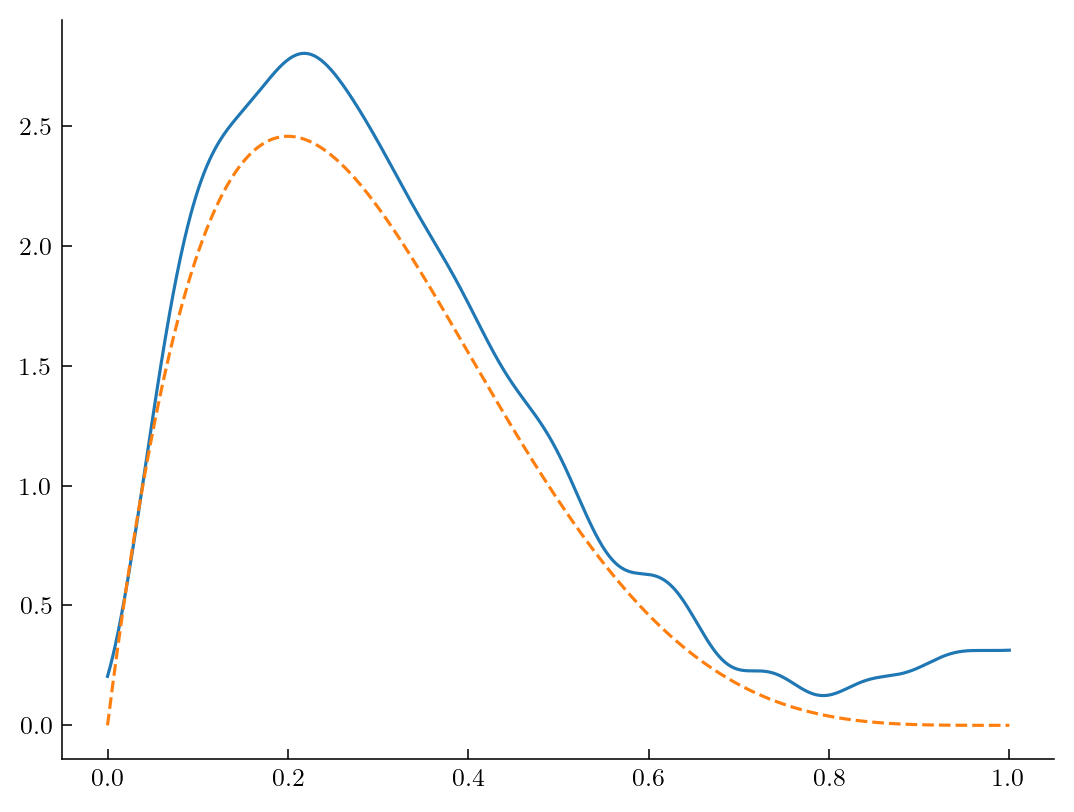

In [7]:
plt.plot(query_beta_xs, beta_sims-xi_beta)
plt.plot(query_beta_xs, true_beta_probs, ls='--', c='tab:orange')

In [8]:
max_rate=50

model = nengo.Network()
with model: 
    ens = nengo.Ensemble(n_neurons=1, 
                        dimensions=x_space.ssp_dim,
                        encoders=np.atleast_2d(mu_beta),
                        radius=train_beta_sims.max(),#np.linalg.norm(mu_beta),
                        gain=max_rate * np.ones((1,)),
                        bias=-xi_beta * max_rate * np.ones((1,)),
                        max_rates=max_rate * np.ones((1,)),
                        normalize_encoders=False,
                        neuron_type=nengo.neurons.RectifiedLinear())
    
sim = nengo.Simulator(model, progress_bar=None)
x_c, beta_spiking_rect = nengo.utils.ensemble.tuning_curves(ens, sim, query_beta_phis)
print(ens.gain, ens.bias, ens.radius)


/home/furlong/miniconda3/lib/python3.10/site-packages/nengo/builder/ensemble.py:113: NengoWarning: Specifying the gains and biases for <Ensemble (unlabeled) at 0x7f984299e470> imposes a set of maximum firing rates and intercepts. Further specifying either max_rates or intercepts has no effect.
  warnings.warn(


[50.] [0.01650914] 2.8033613405054876


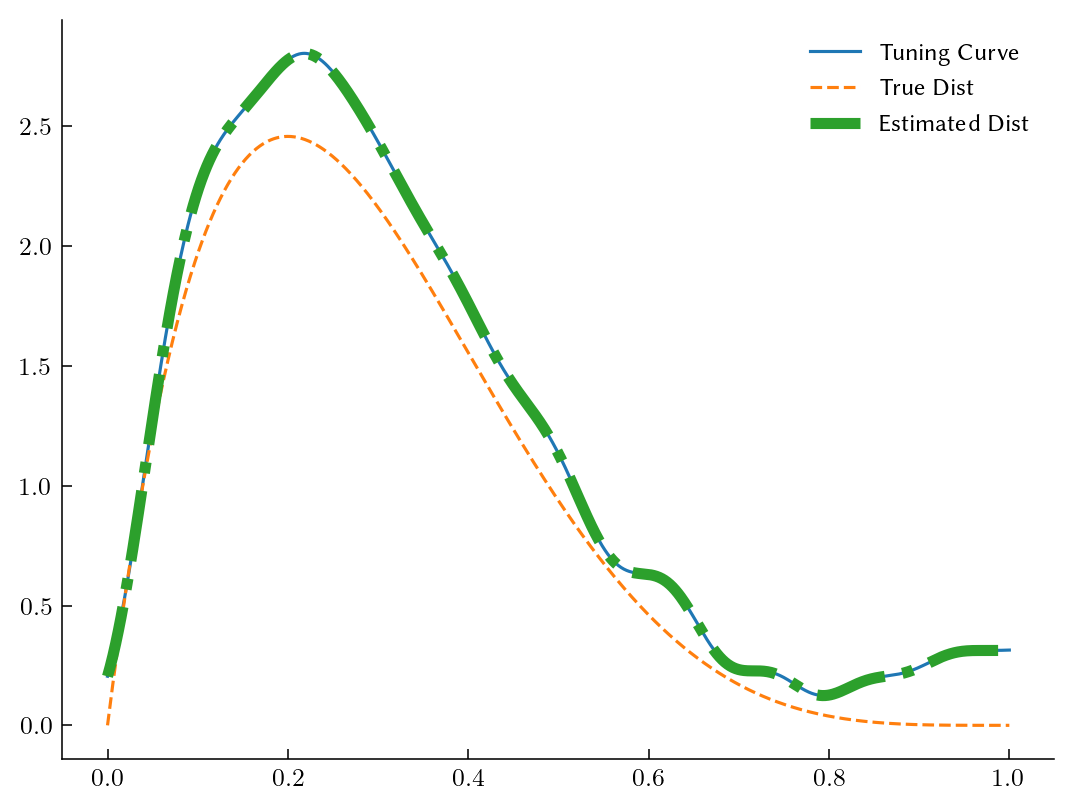

In [9]:

beta_temporal_tuning_curve = beta_spiking_rect[:,0] * beta_sims.max()/max_rate
plt.plot(query_beta_xs, beta_temporal_tuning_curve, label='Tuning Curve')
plt.plot(query_beta_xs, true_beta_probs, ls='--', label='True Dist')
plt.plot(query_beta_xs, beta_sims - xi_beta, ls='-.', lw=4, label='Estimated Dist')
plt.legend()
plt.show()

## Encode Probability in Neural Population

In [14]:

model = nengo.Network()
with model:
    ens = nengo.Ensemble(n_neurons=query_beta_phis.shape[0],
                        dimensions=x_space.ssp_dim,
                        encoders=query_beta_phis, 
                        intercepts = -xi_beta * np.zeros((query_beta_phis.shape[0],)),
                        max_rates=max_rate * np.ones((query_beta_phis.shape[0],)),
                        neuron_type=nengo.neurons.SpikingRectifiedLinear(),
                        )
    def stim_func(t):
        return mu_beta.flatten()
    stim = nengo.Node(stim_func)
    nengo.Connection(stim, ens)
    p_ens = nengo.Probe(ens.neurons)
    
sim_duration = 0.1
with nengo.Simulator(model) as sim:
    sim.run(sim_duration)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

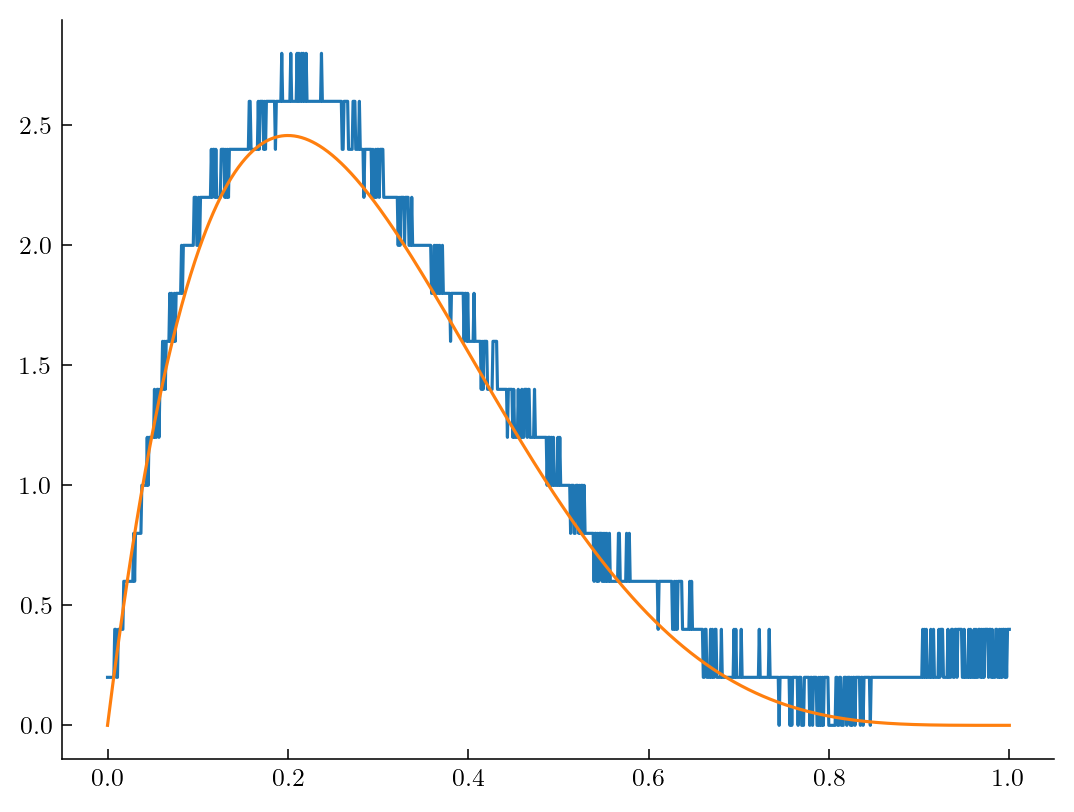

In [15]:
beta_firing_rate = np.mean(sim.data[p_ens], axis=0) / max_rate

plt.figure()
plt.plot(query_beta_xs, beta_firing_rate)
plt.plot(query_beta_xs, true_beta_probs)
plt.show()

# Estimating a Gaussian Mixture Model

In [ ]:
np.random.seed(0)

data_gmm_x, pdf_gmm_x = data.make_data('gmm1d', num_samples=max_samples)
np.random.shuffle(data_gmm_x)
data_gmm_x = data_gmm_x.reshape((-1,1))

query_gmm_xs = np.linspace(-10,10,1000).reshape((-1,1))
dx = (query_gmm_xs.max() - query_gmm_xs.min()) / len(query_gmm_xs)

true_gmm_probs = pdf_gmm_x(query_gmm_xs)

ls_gmm = fie_util.bandwidth_ecf(data_gmm_x, init_h=1) * np.pi
ls_gmm = ls_gmm[0]
#ls_gmm = fie_util.bandwidth_silverman(data_gmm_x)
xi_gmm, f_val_gmm = fie_util.fit_dist(data_gmm_x, -10, 10, ls=ls_gmm)
print(f'ls = {ls_gmm}')
print(f'xi = {xi_gmm}')

In [ ]:
# ls_gmm = estimate_bandwidth(data_gmm_x, quantile=0.3)
# print(ls_gmm)

In [ ]:
x_space = sspspace.RandomSSPSpace(ssp_dim=2048, domain_dim=1)
x_space.update_lengthscale(ls_gmm)

phis_gmm = x_space.encode(data_gmm_x)
mu_gmm = np.mean(phis_gmm, axis=0) / ls_gmm

query_gmm_phis = x_space.encode(query_gmm_xs)

train_gmm_sims = np.einsum('nd,d->n',phis_gmm,mu_gmm.flatten())
gmm_sims = np.einsum('nd,d->n', query_gmm_phis,mu_gmm.flatten())
print(gmm_sims.max())

In [ ]:
max_rate=50

model = nengo.Network()
with model: 
    ens = nengo.Ensemble(n_neurons=1, 
                        dimensions=x_space.ssp_dim,
                        encoders=np.atleast_2d(mu_gmm),
                        radius=train_gmm_sims.max(),
                        max_rates=max_rate * np.ones((1,)),
                        gain=[max_rate],
                        bias=(-xi_gmm*max_rate),
                        normalize_encoders=False,
                        neuron_type=nengo.neurons.SpikingRectifiedLinear())
    
sim = nengo.Simulator(model, progress_bar=None)
x_c, a_spiking_rect = nengo.utils.ensemble.tuning_curves(ens, sim, query_gmm_phis)

gmm_temporal_tuning_curve = a_spiking_rect[:,0] * train_gmm_sims.max() / max_rate


In [ ]:

plt.plot(query_gmm_xs, gmm_temporal_tuning_curve)
plt.plot(query_gmm_xs, np.einsum('nd,d->n', query_gmm_phis, mu_gmm.flatten()), ls='-.')
plt.plot(query_gmm_xs, true_gmm_probs, ls='--')
plt.show()

In [ ]:

model = nengo.Network()
with model:
    ens = nengo.Ensemble(n_neurons=query_gmm_phis.shape[0],
                        dimensions=x_space.ssp_dim,
                        encoders=query_gmm_phis,
                        gain=max_rate * np.ones((query_gmm_phis.shape[0],)),
                        bias=(-xi_gmm * max_rate) * np.ones((query_gmm_phis.shape[0],)),
                        neuron_type=nengo.neurons.SpikingRectifiedLinear(),
                        )
    def stim_func(t):
        return mu_gmm.flatten()
    stim = nengo.Node(stim_func)
    nengo.Connection(stim, ens)
    p_ens = nengo.Probe(ens.neurons)
    
with nengo.Simulator(model) as sim:
    sim.run(sim_duration)

In [ ]:
gmm_firing_rate = np.mean(sim.data[p_ens], axis=0) / max_rate

plt.figure()
plt.plot(query_gmm_xs, gmm_firing_rate)
plt.plot(query_gmm_xs, true_gmm_probs, ls='--')
plt.show()

# Make a KDE Estimator as Baseline

In [ ]:
from sklearn.neighbors import KernelDensity
print(ls_beta, ls_gmm)

beta_kde = KernelDensity(kernel='gaussian', bandwidth=ls_beta).fit(data_beta_x)
beta_pred = np.exp(beta_kde.score_samples(query_beta_xs))

gmm_kde = KernelDensity(kernel='gaussian', bandwidth=ls_gmm).fit(data_gmm_x)
gmm_pred = np.exp(gmm_kde.score_samples(query_gmm_xs))

# Combined Figure

In [ ]:
#fig, (ax1, ax2) = plt.subplots(2,
#                               2,
#                               figsize=(5.75, 5.75),
#                               gridspec_kw={
#                                   "wspace": 0.3,
#                                   "width_ratios": [1,1]
#                               })

#for spine in ["left", "bottom"]:
#    ax1.spines[spine].set_visible(False)
#ax1.set_xticks([])
#ax1.set_yticks([])

#ax1.set_xlim(-1, 4)
#ax1.ylim(0, 0.4)

gmm_sims = np.einsum('nd,d->n', query_gmm_phis, mu_gmm.flatten())

plt.figure(figsize=(5.75,5.75))
plt.subplot(2,2,1)
plt.plot(query_beta_xs, beta_temporal_tuning_curve, label='Tuning Curve')
#plt.plot(query_beta_xs, beta_sims, ls='--', c='tab:orange', label='SSP Similarity')
plt.plot(query_beta_xs, beta_pred, ls='-.', c='tab:green', label='KDE Estimate')
plt.fill(query_beta_xs, true_beta_probs, fc='black', alpha=0.2, label='True Distribution')

plt.ylim(0, 3)

plt.title('{Tuning curve}', y=1.025, va="bottom")

plt.ylabel('Normalized Average Activity (a.u.)')
#plt.xlabel('Stimulus $\\vec x \\in [0,1]$')

#plt.legend(loc="upper center", ncol=1, bbox_to_anchor=(0.55, 1.05), columnspacing=1.0, handlelength=2, handletextpad=0.5)


plt.text(-0.2,
         1.0555,
         '\\textbf{A}',
         fontsize=12,
         transform=plt.gca().transAxes,
         va="bottom")
plt.title('{Single Neuron Encoding}', y=1.025, va="bottom", fontsize='xx-large')


stride=15

plt.subplot(2,2,2)
plt.plot(np.arange(1,query_beta_xs.shape[0]+1), beta_firing_rate, '-', label='Normalized Firing Rate')
#plt.plot(np.arange(1,query_beta_xs.shape[0]+1), beta_sims, ls='--', c='tab:orange', label='SSP Similarity')
plt.plot(np.arange(1,query_beta_xs.shape[0]+1), beta_pred, ls='-.', c='tab:green', label='KDE Estimate')
plt.fill(np.arange(1,query_beta_xs.shape[0]+1), true_beta_probs, fc='black', alpha=0.2, label='True Distribution')
plt.ylim(0, 3)


plt.text(-0.1,
         1.0555,
         '\\textbf{B}',
         fontsize=12,
         transform=plt.gca().transAxes,
         va="bottom")

plt.title('{Population Encoding}', y=1.025, va="bottom", fontsize='xx-large')
#ax2.set_ylabel('Normalized Average Activity $a_i(\\vec{x})$ / $a_\\mathrm{max}$')
#plt.xlabel('Neuron Number')


#plt.legend(loc="upper center", ncol=1, bbox_to_anchor=(0.55, 1.05), columnspacing=1.0, handlelength=2, handletextpad=0.5)

### plot GMM results
plt.subplot(2,2,3)
plt.plot(query_gmm_xs, gmm_temporal_tuning_curve, label='Tuning Curve')
#plt.plot(query_gmm_xs, gmm_sims-xi_gmm, ls='--', c='tab:orange', label='SSP Similarity')
plt.plot(query_gmm_xs, gmm_pred, ls='-.', c='tab:green', label='KDE Estimate')
plt.fill(query_gmm_xs, true_gmm_probs, fc='black', alpha=0.2, label='True Distribution')

plt.ylim(0, 0.5)

#plt.title('{Tuning curve}', y=1.025, va="bottom")

plt.ylabel('Normalized Average Activity (a.u.)')
plt.xlabel('Stimulus $x$', fontsize='xx-large')

#plt.legend(loc="upper center", ncol=4, bbox_to_anchor=(1.1, -0.2), columnspacing=1.0, handlelength=2, handletextpad=0.5)


plt.text(-0.2,
         1.0555,
         '\\textbf{C}',
         fontsize=12,
         transform=plt.gca().transAxes,
         va="bottom")
#plt.title('{Single Neuron Encoding}', x=0.66, y=1.025, va="bottom")


stride=15

plt.subplot(2,2,4)
plt.plot(np.arange(1,query_gmm_xs.shape[0]+1), gmm_firing_rate, '-', markersize=1, lw=1, label='Normalized Firing Rate')
#plt.plot(np.arange(1,query_gmm_xs.shape[0]+1), gmm_sims-xi_gmm, ls='--', c='tab:orange', label='SSP Similarity')
plt.plot(np.arange(1,query_gmm_xs.shape[0]+1), gmm_pred, ls='-.', c='tab:green', label='KDE Estimate')
plt.fill(np.arange(1,query_gmm_xs.shape[0]+1), true_gmm_probs, fc='black', alpha=0.2, label='True Distribution')
plt.ylim(0, 0.5)


plt.text(-0.1,
         1.0555,
         '\\textbf{D}',
         fontsize=12,
         transform=plt.gca().transAxes,
         va="bottom")

#plt.title('{Population Encoding}', y=1.025, va="bottom")
#ax2.set_ylabel('Normalized Average Activity $a_i(\\vec{x})$ / $a_\\mathrm{max}$')
plt.xlabel('Neuron Number', fontsize='xx-large')


#plt.legend(loc="upper center", ncol=1, bbox_to_anchor=(0.55, 1.05), columnspacing=1.0, handlelength=2, handletextpad=0.5)
plt.legend(loc="upper center", ncol=4, bbox_to_anchor=(-0.1, -0.2), columnspacing=1.0, handlelength=2, handletextpad=0.5)




#plt.show()
plt.savefig('../output/probability_distributions.pdf')
#utils.save(fig, "probability_tuning_curve.pdf")